In [1]:
# Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Generación y visualización de la cardioide ideal

Se genera la señal ideal (cardioide) y se grafica en el plano cartesiano.

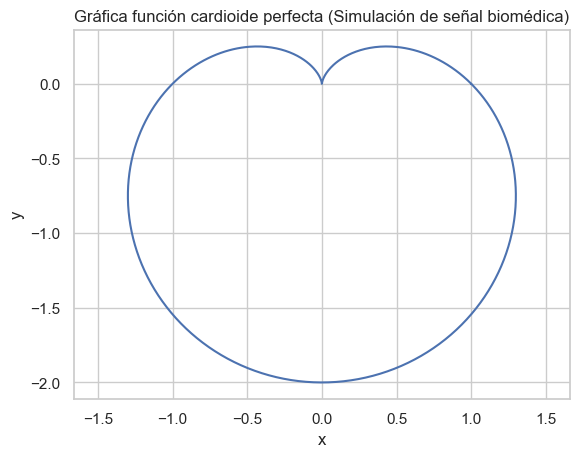

In [2]:
# Generar la señal ideal (cardioide)
theta = np.linspace(0, 2*np.pi, 500)
r = 1 - np.sin(theta)

# Coordenadas cartesianas
x = r * np.cos(theta)
y = r * np.sin(theta)

# Graficar la cardioide ideal
plt.plot(x, y)
plt.axis('equal')
plt.title('Gráfica función cardioide perfecta (Simulación de señal biomédica)')
plt.grid(True)
plt.ylabel('y')
plt.xlabel('x')
plt.show()

## 2. Guardar y cargar la señal ideal

Se guarda la señal ideal en un archivo CSV y se vuelve a cargar para simular un flujo de trabajo real.

In [3]:
# Guardar la señal como DataFrame y exportar a CSV
valores = {
    'theta': theta,
    'amplitud': r
}
df_graph = pd.DataFrame(valores)
df_graph.to_csv('datosGraphCardeoide.csv', index=False)

# Leer el archivo CSV
df_analizar = pd.read_csv('datosGraphCardeoide.csv')

# Convertir columnas a tipo numérico
for col in ['theta', 'amplitud']:
    df_analizar[col] = pd.to_numeric(df_analizar[col], errors='coerce')

df_analizar.head(10)

,theta,amplitud
0,0.000000,1.000000
1,0.012592,0.987409
2,0.025183,0.974820
3,0.037775,0.962234
4,0.050366,0.949655
5,0.062958,0.937084
6,0.075549,0.924523
7,0.088141,0.911973
8,0.100732,0.899438
9,0.113324,0.886918


## 3. Perturbación de la señal: ruido, nulos y atípicos

Se añade ruido gaussiano, valores nulos y valores atípicos a la señal para simular problemas reales en señales biomédicas.

In [4]:
# Añadir ruido gaussiano
df_analizar['amplitud_ruido'] = df_analizar['amplitud'] + np.random.normal(0, 0.1, size=len(df_analizar))

# Añadir valores nulos (NaN)
nan_indices = np.random.choice(df_analizar.index, 15, replace=False)
df_analizar.loc[nan_indices, 'amplitud_ruido'] = np.nan

# Añadir valores atípicos (outliers)
outlier_indices = np.random.choice(df_analizar.index.difference(nan_indices), 10, replace=False)
df_analizar.loc[outlier_indices, 'amplitud_ruido'] += np.random.normal(2, 0.7, size=10)

df_analizar.to_csv('senial_cardioide_perturbada.csv', index=False)

## 4. Visualización de la señal perturbada

Se grafica la señal cardioide con ruido, nulos y valores atípicos en el plano cartesiano.

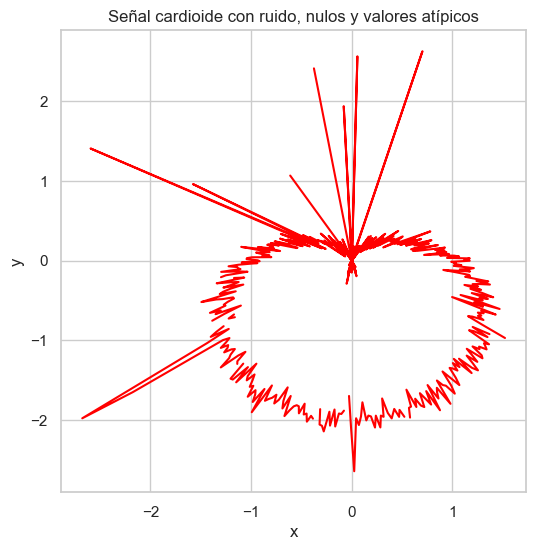

In [5]:
# Graficar señal cardioide perturbada en el plano cartesiano
x_ruido = df_analizar['amplitud_ruido'] * np.cos(df_analizar['theta'])
y_ruido = df_analizar['amplitud_ruido'] * np.sin(df_analizar['theta'])
plt.figure(figsize=(6,6))
plt.plot(x_ruido, y_ruido, color='red')
plt.ylabel('y')
plt.xlabel('x')
plt.title('Señal cardioide con ruido, nulos y valores atípicos')
plt.grid(True)
plt.show()

## 5. Diagnóstico estadístico y visual

Se realiza un análisis estadístico y visual de la señal perturbada.

count    485.000000
mean       1.040930
std        0.724694
min       -0.292844
25%        0.351967
50%        1.088380
75%        1.708240
max        3.326528
Name: amplitud_ruido, dtype: float64
Cantidad de valores nulos: 15


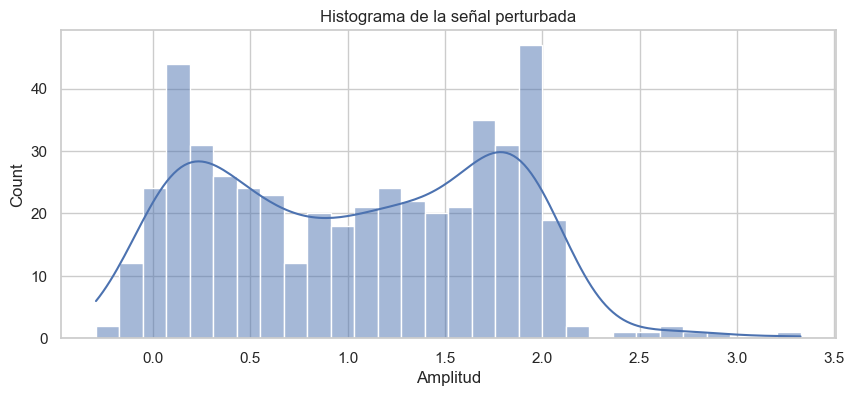

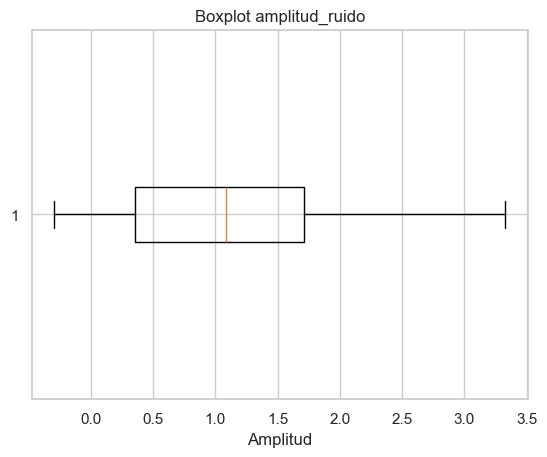

In [6]:
# Estadísticas y visualización de la señal perturbada
print(df_analizar['amplitud_ruido'].describe())
print("Cantidad de valores nulos:", df_analizar['amplitud_ruido'].isna().sum())

plt.figure(figsize=(10,4))
sns.histplot(df_analizar['amplitud_ruido'].dropna(), bins=30, kde=True)
plt.title('Histograma de la señal perturbada')
plt.xlabel('Amplitud')
plt.show()

plt.boxplot(df_analizar['amplitud_ruido'].dropna(), vert=False)
plt.title('Boxplot amplitud_ruido')
plt.xlabel('Amplitud')
plt.show()

## 6. Limpieza y reconstrucción de la señal

Se realiza la imputación de valores nulos y el suavizado mediante media móvil.

In [7]:
# Imputación de NaN por interpolación
df_analizar['amplitud_reconstruida'] = df_analizar['amplitud_ruido'].interpolate()

# Suavizado con media móvil
df_analizar['amplitud_reconstruida'] = df_analizar['amplitud_reconstruida'].rolling(window=7, center=True).mean()
df_analizar['amplitud_reconstruida'] = df_analizar['amplitud_reconstruida'].fillna(method='bfill').fillna(method='ffill')

C:\Users\juann\AppData\Local\Temp\ipykernel_19028\684215996.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_analizar['amplitud_reconstruida'] = df_analizar['amplitud_reconstruida'].fillna(method='bfill').fillna(method='ffill')


## 7. Comparación visual final en coordenadas rectangulares

Se comparan las tres señales (ideal, perturbada y reconstruida) en el plano cartesiano (x-y).

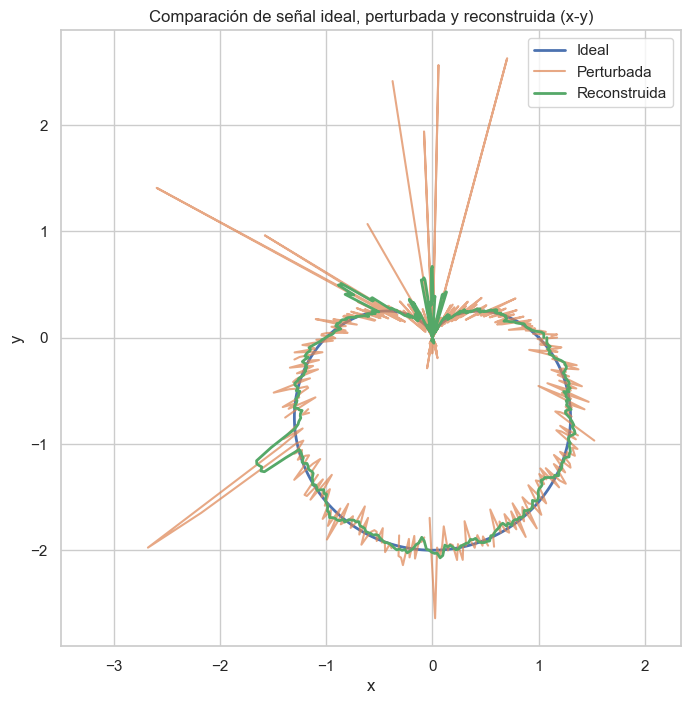

In [8]:
# Graficar las tres señales en el plano cartesiano (x-y)
plt.figure(figsize=(8,8))
# Ideal
x_ideal = df_analizar['amplitud'] * np.cos(df_analizar['theta'])
y_ideal = df_analizar['amplitud'] * np.sin(df_analizar['theta'])
plt.plot(x_ideal, y_ideal, label='Ideal', linewidth=2)
# Perturbada
x_ruido = df_analizar['amplitud_ruido'] * np.cos(df_analizar['theta'])
y_ruido = df_analizar['amplitud_ruido'] * np.sin(df_analizar['theta'])
plt.plot(x_ruido, y_ruido, label='Perturbada', alpha=0.7)
# Reconstruida
x_rec = df_analizar['amplitud_reconstruida'] * np.cos(df_analizar['theta'])
y_rec = df_analizar['amplitud_reconstruida'] * np.sin(df_analizar['theta'])
plt.plot(x_rec, y_rec, label='Reconstruida', linewidth=2)
plt.legend()
plt.title('Comparación de señal ideal, perturbada y reconstruida (x-y)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True)
plt.show()